# Лабораторная работа: бустинг

Цель работы — исследовать, как ведут себя методы бустинга при изменении основных параметров.

В отчете должны быть графики, таблицы и краткие выводы. Готовый шаблон кода не требуется.

---

## Задача 1. AdaBoost и сложность базовых деревьев

Возьмите двумерную задачу классификации, например `make_moons` или `make_circles`.

Сравните AdaBoost с базовыми деревьями разной глубины:

$$
\text{max\_depth}=1,\quad 2,\quad 3.
$$

Изменяйте число деревьев:

$$
M=5,\ 10,\ 20,\ 50,\ 100.
$$

### Что сделать

1. Постройте графики train/test accuracy от числа деревьев.
2. Для нескольких моделей нарисуйте границу классификации.
3. Опишите, как глубина дерева влияет на недообучение и переобучение.

---

## Задача 2. Learning rate и число деревьев

Возьмите задачу регрессии или классификации.

Обучите градиентный бустинг при разных learning rate:

$$
\nu=1.0,\ 0.3,\ 0.1,\ 0.03.
$$

Для каждого значения $\nu$ рассмотрите разные числа деревьев:

$$
M=10,\ 30,\ 100,\ 300.
$$

### Что сделать

1. Сравните качество на train и test.
2. Постройте графики ошибки от числа деревьев.
3. Найдите удачное сочетание $\nu$ и $M$.

### Что обсудить

1. Что происходит при слишком большом learning rate?
2. Почему маленький learning rate требует больше деревьев?
3. Где видно переобучение?

---

## Задача 3. Классический и histogram-based бустинг

Выберите один табличный датасет.

Сравните две реализации из `scikit-learn`:

- `GradientBoostingClassifier` или `GradientBoostingRegressor`;
- `HistGradientBoostingClassifier` или `HistGradientBoostingRegressor`.

### Что сделать

1. Сравните качество моделей на test.
2. Сравните время обучения.
3. Добавьте искусственные пропуски в данные.
4. Проверьте, какая модель может работать с `NaN` напрямую.

### Что обсудить

1. Чем histogram-based подход отличается от обычного?
2. Ускорилось ли обучение?
3. Как обработка пропусков повлияла на результат?

---

## Задача 4. XGBoost, LightGBM, CatBoost

Выберите один табличный датасет и сравните современные реализации бустинга:

- XGBoost;
- LightGBM;
- CatBoost.

Можно сравнить их также с `HistGradientBoosting`.

### Что сделать

1. Обучите 2–3 современные реализации бустинга.
2. Сравните качество на train и test.
3. Сравните время обучения.
4. Проверьте работу с пропусками.
5. Если в данных есть категориальные признаки, сравните способы их обработки.

### Что обсудить

1. Чем XGBoost отличается от обычного gradient boosting?
2. Какие особенности LightGBM удалось увидеть в эксперименте?
3. Удобен ли CatBoost для категориальных признаков?
4. Какая реализация оказалась лучшей по балансу качества, скорости и удобства?

---

## Итоговый вывод

В конце работы кратко ответьте:

1. Какие параметры бустинга оказались наиболее важными?
2. Где наблюдалось переобучение?
3. Какая модель показала лучший баланс качества, скорости и простоты?

# Задача 1

In [8]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

In [19]:
X, y = make_moons(n_samples=1000, random_state=42, noise=0.25)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [20]:
depths = [1, 2, 3]
n_estimators_list = [5, 10, 20, 50, 100]

results = {}

In [21]:
for depth in depths:

    train_scores = []
    test_scores = []

    for n_estimators in n_estimators_list:

        base_tree = DecisionTreeClassifier(
            max_depth=depth,
            random_state=42
        )

        model = AdaBoostClassifier(
            estimator=base_tree,
            n_estimators=n_estimators,
            random_state=42
        )

        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc = accuracy_score(y_test, y_test_pred)

        train_scores.append(train_acc)
        test_scores.append(test_acc)

        print(
            f"depth={depth}, "
            f"M={n_estimators}, "
            f"train={train_acc:.3f}, "
            f"test={test_acc:.3f}"
        )

    results[depth] = {
        "train": train_scores,
        "test": test_scores
    }

depth=1, M=5, train=0.909, test=0.903
depth=1, M=10, train=0.904, test=0.897
depth=1, M=20, train=0.907, test=0.900
depth=1, M=50, train=0.951, test=0.950
depth=1, M=100, train=0.959, test=0.950
depth=2, M=5, train=0.933, test=0.927
depth=2, M=10, train=0.960, test=0.960
depth=2, M=20, train=0.963, test=0.953
depth=2, M=50, train=0.966, test=0.950
depth=2, M=100, train=0.977, test=0.943
depth=3, M=5, train=0.950, test=0.927
depth=3, M=10, train=0.959, test=0.933
depth=3, M=20, train=0.974, test=0.950
depth=3, M=50, train=1.000, test=0.943
depth=3, M=100, train=1.000, test=0.937


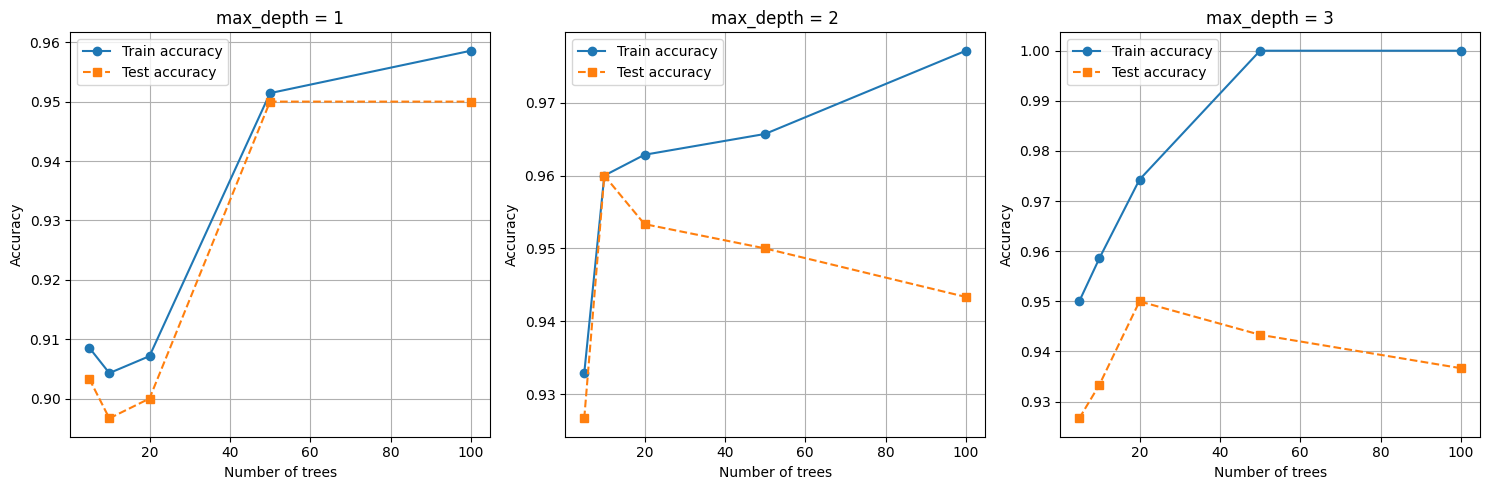

In [22]:
fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5)
)

for idx, depth in enumerate(depths):

    ax = axes[idx]

    ax.plot(
        n_estimators_list,
        results[depth]["train"],
        marker='o',
        label='Train accuracy'
    )

    ax.plot(
        n_estimators_list,
        results[depth]["test"],
        marker='s',
        linestyle='--',
        label='Test accuracy'
    )

    ax.set_title(f"max_depth = {depth}")
    ax.set_xlabel("Number of trees")
    ax.set_ylabel("Accuracy")

    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

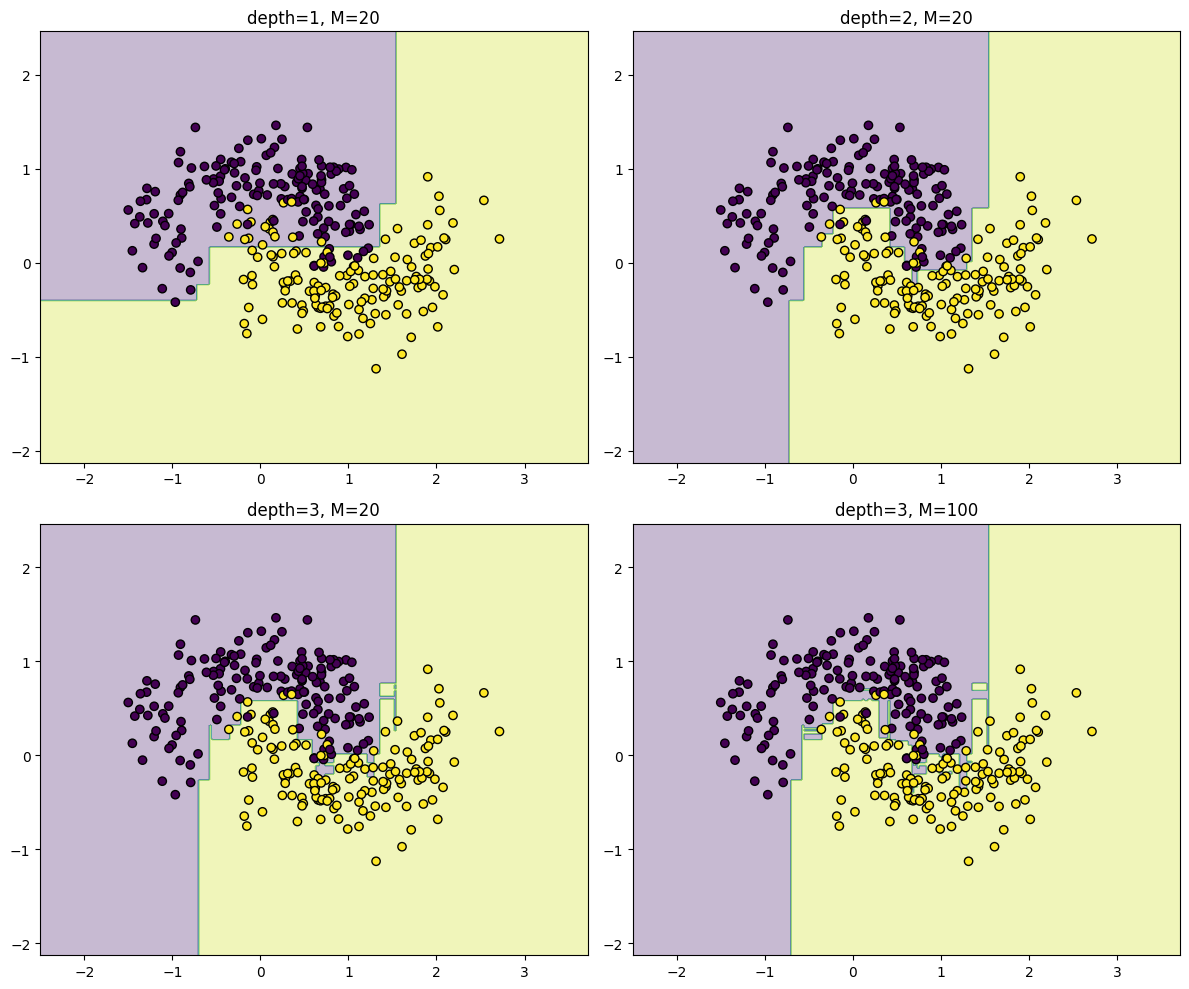

In [13]:
def plot_decision_boundary(model, X, y, title):

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    probs = model.predict(grid)
    probs = probs.reshape(xx.shape)

    plt.contourf(xx, yy, probs, alpha=0.3)

    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        edgecolors='k'
    )

    plt.title(title)


configs = [
    (1, 20),
    (2, 20),
    (3, 20),
    (3, 100)
]

plt.figure(figsize=(12, 10))

for i, (depth, n_estimators) in enumerate(configs, 1):

    base_tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model = AdaBoostClassifier(
        estimator=base_tree,
        n_estimators=n_estimators,
        random_state=42
    )

    model.fit(X_train, y_train)

    plt.subplot(2, 2, i)

    plot_decision_boundary(
        model,
        X_test,
        y_test,
        f"depth={depth}, M={n_estimators}"
    )

plt.tight_layout()
plt.show()

### Вывод
 Большая глубина дерева - это верный способ переобучиться. Так как деревья решений по своей сути аппроксимируют кусочно-постоянную функцию, они могут легко подстроиться под всю обучающую выборку и идеально её разделить. Кроме того, AdaBoost при большой глубине дерева концентрируется на шумных и трудноклассифицируемых экземплярах, поэтому на практике стараются ограничиться глубиной дерева не больше 3

# Задача 2

In [33]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons, make_circles
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import log_loss


# Данные
X, y = make_circles(
    n_samples=3000,
    noise=0.25,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

# Параметры

learning_rates = [1.0, 0.3, 0.1, 0.03]
n_estimators_list = [10, 30, 100, 300]

results = {}

In [38]:
for lr in learning_rates:

    train_scores = []
    test_scores = []

    for n_estimators in n_estimators_list:

        model = GradientBoostingClassifier(
            learning_rate=lr,
            n_estimators=n_estimators,
            max_depth=3,
            random_state=42
        )

        model.fit(X_train, y_train)

        y_train_pred = model.predict_proba(X_train)
        y_test_pred = model.predict_proba(X_test)
        train_entropy = log_loss(y_true=y_train, y_pred=y_train_pred)
        test_entropy = log_loss(y_true=y_test, y_pred=y_test_pred)

        # train_acc = accuracy_score(y_train, y_train_pred)
        # test_acc = accuracy_score(y_test, y_test_pred)

        train_scores.append(train_entropy)
        test_scores.append(test_entropy)

        print(
            f"lr={lr}, "
            f"M={n_estimators}, "
            f"train={train_entropy:.3f}, "
            f"test={test_entropy:.3f}"
        )

    results[lr] = {
        "train": train_scores,
        "test": test_scores
    }

lr=1.0, M=10, train=0.560, test=0.692
lr=1.0, M=30, train=0.460, test=0.798
lr=1.0, M=100, train=0.255, test=0.962
lr=1.0, M=300, train=0.051, test=1.291
lr=0.3, M=10, train=0.598, test=0.651
lr=0.3, M=30, train=0.549, test=0.661
lr=0.3, M=100, train=0.444, test=0.695
lr=0.3, M=300, train=0.267, test=0.790
lr=0.1, M=10, train=0.638, test=0.666
lr=0.1, M=30, train=0.599, test=0.655
lr=0.1, M=100, train=0.544, test=0.659
lr=0.1, M=300, train=0.444, test=0.688
lr=0.03, M=10, train=0.670, test=0.682
lr=0.03, M=30, train=0.642, test=0.667
lr=0.03, M=100, train=0.600, test=0.655
lr=0.03, M=300, train=0.552, test=0.656


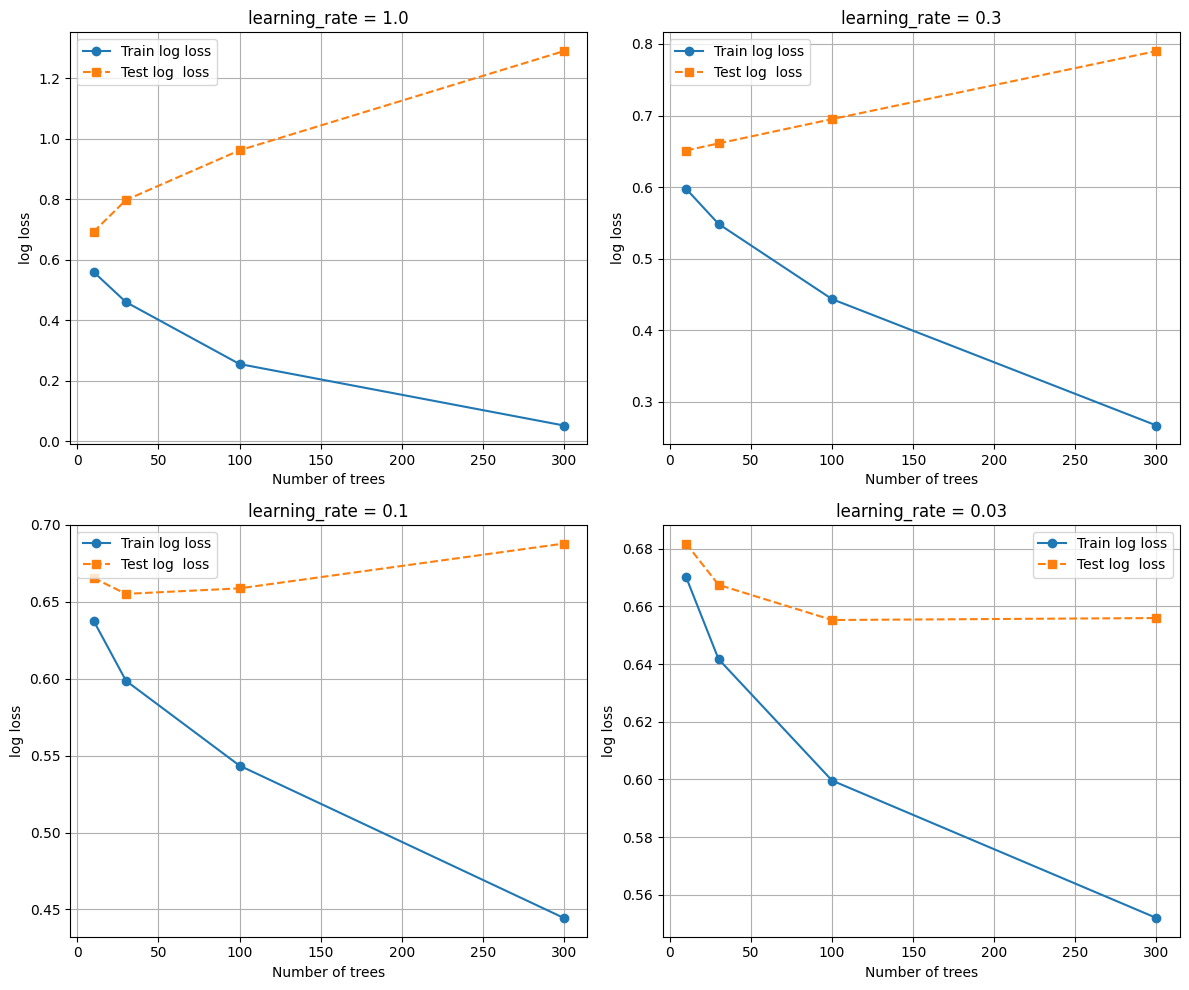

In [39]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 10)
)

axes = axes.ravel()

for idx, lr in enumerate(learning_rates):

    ax = axes[idx]

    ax.plot(
        n_estimators_list,
        results[lr]["train"],
        marker='o',
        label='Train log loss'
    )

    ax.plot(
        n_estimators_list,
        results[lr]["test"],
        marker='s',
        linestyle='--',
        label='Test log  loss'
    )

    ax.set_title(f"learning_rate = {lr}")
    ax.set_xlabel("Number of trees")
    ax.set_ylabel("log loss")

    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

1. Что происходит при слишком большом learning rate?
2. Почему маленький learning rate требует больше деревьев?
3. Где видно переобучение?

---

1. При большом learning rate каждое новое дерево делает слишком большой шаг при обновлении модели. Из-за этого градиентный бустинг начинает слишком быстро подстраиваться под обучающую выборку, включая шумовые объекты. В результате ошибка на train уменьшается очень быстро, но ошибка на test начинает расти, что приводит к переобучению.

2. Маленький learning rate уменьшает вклад каждого отдельного дерева в итоговую модель. При маленьком значении ν модель обучается более плавно и устойчиво, однако каждое дерево исправляет ошибку лишь незначительно. Поэтому для достижения хорошего качества требуется большее число деревьев.

3. Переобучение видно по расхождению между ошибкой на обучающей и тестовой выборках.



# Задача 3

In [42]:
import time
import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

def train_eval(model, name, X_train, y_train, X_test, y_test):
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)

    print(f"{name}")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  Time: {train_time:.4f} sec\n")

gb = GradientBoostingClassifier(random_state=42)
hgb = HistGradientBoostingClassifier(random_state=42)

train_eval(gb, "GradientBoosting", X_train, y_train, X_test, y_test)
train_eval(hgb, "HistGradientBoosting", X_train, y_train, X_test, y_test)

GradientBoosting
  Accuracy: 0.9561
  Time: 1.4017 sec

HistGradientBoosting
  Accuracy: 0.9737
  Time: 0.5885 sec



In [47]:
rng = np.random.RandomState(42)

X_nan = X.copy()
mask = rng.rand(*X_nan.shape) < 0.1  # 10% пропусков
X_nan[mask] = np.nan

X_train_nan, X_test_nan, y_train, y_test = train_test_split(
    X_nan, y, test_size=0.2, random_state=42, stratify=y
)

try:
  train_eval(gb, "GradientBoosting", X_train_nan, y_train, X_test_nan, y_test)
except Exception as e:
  print(e)
train_eval(hgb, "HistGradientBoosting", X_train_nan, y_train, X_test_nan, y_test)

Input X contains NaN.
GradientBoostingClassifier does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values
HistGradientBoosting
  Accuracy: 0.9474
  Time: 0.7342 sec



1. Histogram-based градиентный бустинг отличается от классического тем, что вместо перебора всех уникальных значений признаков он предварительно разбивает данные на фиксированные интервалы (бины) и ищет лучшие разбиения только по их границам. Это снижает вычислительную сложность и делает алгоритм более эффективным по памяти и времени.

2. Обучение ускорилось. Это связано с уменьшением числа кандидатов для сплита и более эффективной работой с памятью и кэшом.

3. Обработка пропусков повлияла положительно: histogram-based модель может работать с NaN напрямую, автоматически обучаясь, как направлять пропущенные значения в деревьях. В классическом бустинге требуется предварительная обработка.

# Задача 4

In [52]:
! pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.9 MB/s eta 0:00:00


In [57]:
import pandas as pd
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score
import seaborn as sns

# Импорт бустингов
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
from sklearn.ensemble import HistGradientBoostingClassifier

In [58]:
df = sns.load_dataset('titanic')

features = ['pclass', 'sex', 'age', 'fare', 'embarked']
target = 'survived'

X = df[features].copy()
y = df[target].copy()

for col in ['sex', 'embarked', 'pclass']:
    X[col] = X[col].fillna('missing').astype(str).astype('category')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [59]:
def train_and_evaluate(model, name, X_train, y_train, X_test, y_test, **fit_params):
    print(f"--- {name} ---")
    start_time = time.time()

    # Обучение
    model.fit(X_train, y_train, **fit_params)
    train_time = time.time() - start_time

    # Предсказание
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    y_proba_test = model.predict_proba(X_test)[:, 1]

    # Метрики
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)
    roc_auc = roc_auc_score(y_test, y_proba_test)

    print(f"Время обучения: {train_time:.4f} сек")
    print(f"Accuracy (Train): {acc_train:.4f}")
    print(f"Accuracy (Test):  {acc_test:.4f}")
    print(f"ROC-AUC (Test):   {roc_auc:.4f}\n")
    return train_time

In [61]:
# Указываем, какие колонки являются категориальными (индексы или названия)
cat_features_names = ['sex', 'embarked', 'pclass']

xgb_model = xgb.XGBClassifier(n_estimators=100, enable_categorical=True, random_state=42, use_label_encoder=False, eval_metric='logloss')
train_and_evaluate(xgb_model, "XGBoost", X_train, y_train, X_test, y_test)

lgb_model = lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
train_and_evaluate(lgb_model, "LightGBM", X_train, y_train, X_test, y_test)

cb_model = cb.CatBoostClassifier(n_estimators=100, random_state=42, verbose=0)
train_and_evaluate(cb_model, "CatBoost", X_train, y_train, X_test, y_test, cat_features=cat_features_names)

hgb_model = HistGradientBoostingClassifier(random_state=42, categorical_features=[0, 1, 4])
train_and_evaluate(hgb_model, "HistGradientBoosting", X_train, y_train, X_test, y_test)

--- XGBoost ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:47:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Время обучения: 0.4443 сек
Accuracy (Train): 0.9691
Accuracy (Test):  0.7989
ROC-AUC (Test):   0.8628

--- LightGBM ---
Время обучения: 0.1042 сек
Accuracy (Train): 0.9522
Accuracy (Test):  0.8212
ROC-AUC (Test):   0.8743

--- CatBoost ---
Время обучения: 0.2292 сек
Accuracy (Train): 0.8399
Accuracy (Test):  0.8045
ROC-AUC (Test):   0.8750

--- HistGradientBoosting ---
Время обучения: 0.4509 сек
Accuracy (Train): 0.9452
Accuracy (Test):  0.8101
ROC-AUC (Test):   0.8746



0.4509131908416748